# Iris demo: MF-based split + MF-targeted synthesis

Minimal demonstration of the two evolutionary branches on the Iris dataset.

1. Random train/test split (baseline) and a pair-plot.
2. Meta-feature-based split via `EvolutionarySplitOptimizer` (NSGA-II, target meta-feature: `mut_inf`).
3. Meta-feature-targeted synthesis via `generate_synthetic_data` (NSGA-III, target meta-features: `mut_inf` + `iq_range` of the MF-split test set).
4. Comparison of meta-feature distances between source / target / synthetic data.

In [1]:
import os, sys, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from pymfe.mfe import MFE

# Local modules from this folder
sys.path.insert(0, os.path.abspath("."))
from mfs_split import EvolutionarySplitOptimizer
from mfs_synthetic import compute_meta_feature, generate_synthetic_data
from ForestDiffusion import ForestDiffusionModel

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED); np.random.seed(SEED)

FEATURES = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
CLASS_NAMES = {0: "setosa", 1: "versicolor", 2: "virginica"}

def compute_mf(df, mfs=("mut_inf", "iq_range")):
    mfe = MFE(features=list(mfs), summary="mean")
    mfe.fit(df[FEATURES].values, df["target"].values)
    names, vals = mfe.extract()
    return dict(zip(names, vals))

def split_pairplot(train_df, test_df, title):
    plot_df = pd.concat([
        train_df.assign(split="train"),
        test_df.assign(split="test"),
    ], ignore_index=True)
    g = sns.pairplot(plot_df, vars=FEATURES, hue="split", diag_kind="kde",
                     plot_kws={"alpha": 0.6, "s": 30},
                     palette={"train": "#1f77b4", "test": "#d62728"})
    g.fig.suptitle(title, y=1.02, fontweight="bold")
    plt.show()

## 1. Load Iris

In [2]:
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=FEATURES)
iris_df["target"] = iris.target
print("Shape:", iris_df.shape, "| classes:", iris_df["target"].value_counts().to_dict())

Shape: (150, 5) | classes: {0: 50, 1: 50, 2: 50}


## 2. Random split (baseline)

train MF: {'iq_range.mean': 1.70625, 'mut_inf.mean': 0.8495826449348935}
test  MF: {'iq_range.mean': 1.6875, 'mut_inf.mean': 0.8886381542807129}


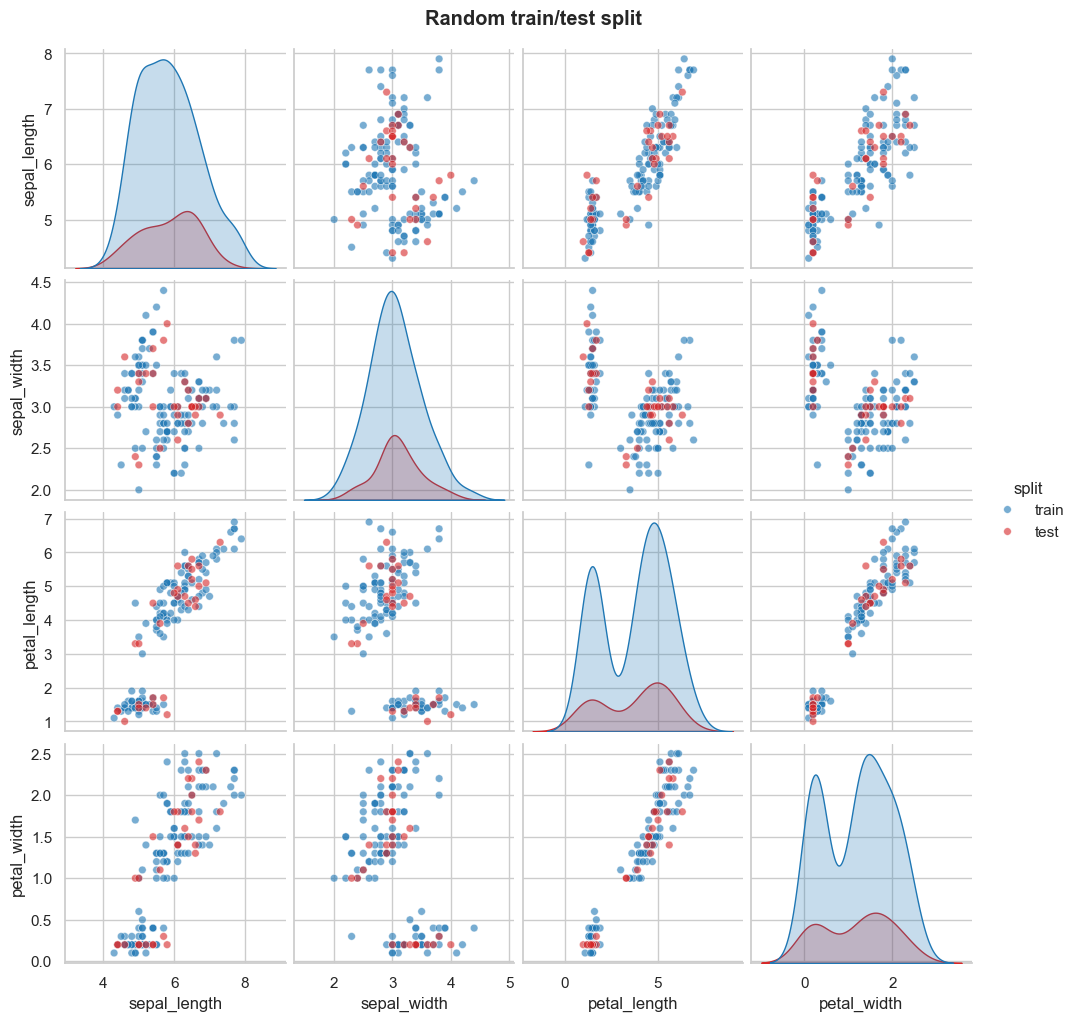

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(
    iris_df[FEATURES].values, iris_df["target"].values,
    test_size=0.2, random_state=SEED, stratify=iris_df["target"].values,
)
rand_train = pd.DataFrame(X_tr, columns=FEATURES).assign(target=y_tr)
rand_test  = pd.DataFrame(X_te, columns=FEATURES).assign(target=y_te)

print("train MF:", compute_mf(rand_train))
print("test  MF:", compute_mf(rand_test))
split_pairplot(rand_train, rand_test, "Random train/test split")

## 3. MF-based split (NSGA-II, target = `mut_inf`)

`EvolutionarySplitOptimizer` searches for a partition that maximizes the divergence between train and test in the chosen meta-feature.

Metafeatures: ['mut_inf.mean']
train MF: {'iq_range.mean': 1.8875000000000004, 'mut_inf.mean': 0.8099178995098116}
test  MF: {'iq_range.mean': 0.3249999999999999, 'mut_inf.mean': 0.04870816629926872}


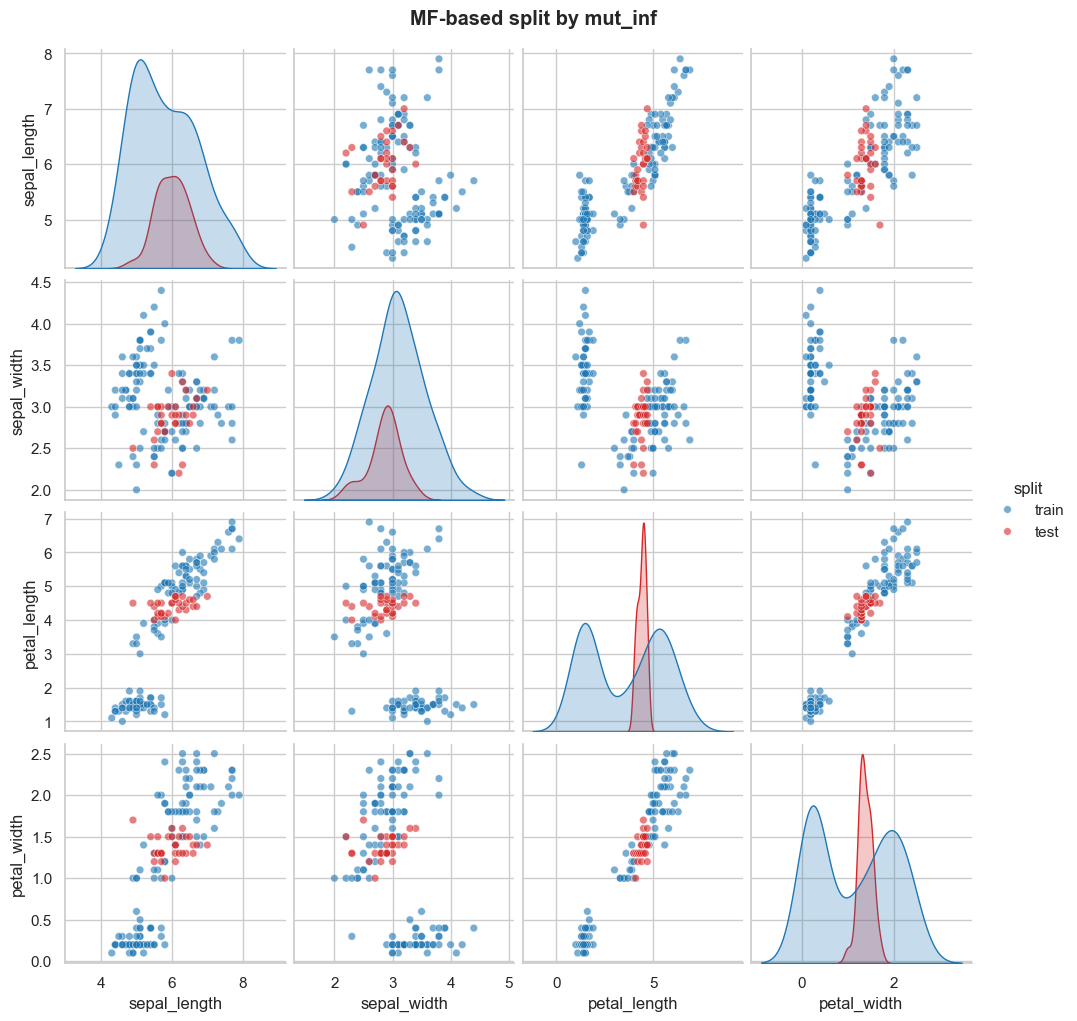

In [4]:
optimizer = EvolutionarySplitOptimizer(
    X=iris_df[FEATURES].values,
    y=iris_df["target"].values,
    test_size=0.2,
    meta_features=["mut_inf"],
    population_size=40,
    generations=25,
    random_state=SEED,
    file=iris_df.copy(),
)
results = optimizer.optimize(verbose=False)
best = optimizer.get_split_details(results["best_solutions"][0])

mfs_train = pd.DataFrame(best["X_train"], columns=FEATURES).assign(target=best["y_train"])
mfs_test  = pd.DataFrame(best["X_test"],  columns=FEATURES).assign(target=best["y_test"])

print("train MF:", compute_mf(mfs_train))
print("test  MF:", compute_mf(mfs_test))
split_pairplot(mfs_train, mfs_test, "MF-based split by mut_inf")

## 4. MF-targeted synthesis (NSGA-III)

Take the MF-split test as the **target profile** and generate synthetic data from the MF-split train so that its `mut_inf` and `iq_range` match the target.

In [6]:
META = ["mut_inf", "iq_range"]

source_df = mfs_train.reset_index(drop=True)
target_df = mfs_test.reset_index(drop=True)
target_meta = {mf: compute_meta_feature(target_df, mf) for mf in META}

forest = ForestDiffusionModel(
    source_df.to_numpy(),
    n_t=2, duplicate_K=3,
    bin_indexes=[], cat_indexes=[], int_indexes=[],
    diffusion_type="flow", n_jobs=-1,
)

synth_data, _, _, meta_values = generate_synthetic_data(
    mutation_type="all",
    source_data=source_df,
    meta_features=META,
    target_meta_values=target_meta,
    population_size=20,
    generations=50,
    mutation_prob=0.6,
    crossover_prob=0.2,
    forest_diffusion=forest,
)
synth_df = synth_data if isinstance(synth_data, pd.DataFrame) else pd.DataFrame(synth_data, columns=source_df.columns)
synth_df["target"] = synth_df["target"].round().clip(0, 2).astype(int)

for mf in META:
    print(f"{mf}\n  initial={meta_values['initial'][mf]}\n  target ={meta_values['target'][mf]}\n  final  ={meta_values['final'][mf]}")

gen	nevals	min                    	avg                    	std                    
0  	20    	[3.32982805 1.32952345]	[3.59629234 1.98395244]	[0.13400797 0.8256861 ]
1  	19    	[0.0615703  1.31265173]	[2.98976455 1.53210928]	[1.46214343 0.14855023]
2  	15    	[0.0615703  1.31265173]	[2.83260134 1.48216176]	[1.59617232 0.0988765 ]
3  	14    	[0.06195745 1.31265173]	[2.67457181 1.44861165]	[1.70485928 0.08580254]
4  	13    	[0.07823798 1.31265173]	[2.87442485 1.44603836]	[1.61752301 0.10257085]
5  	16    	[0.06258807 1.24037836]	[2.16897447 1.37911687]	[1.80517788 0.10366274]
6  	17    	[0.07307265 1.13228957]	[1.98007588 1.34191677]	[1.81502986 0.10863927]
7  	13    	[0.0634803  1.13228957]	[2.1534844  1.32280475]	[1.79301733 0.11331729]
8  	15    	[0.0634803  1.13228957]	[2.39455845 1.31945508]	[1.71192186 0.12696421]
9  	14    	[0.0634803  1.13228957]	[2.78201149 1.34737787]	[1.67519066 0.16721766]
10 	19    	[0.07286085 0.95901412]	[2.92481644 1.3602693 ]	[1.64417732 0.18633813]
11 	

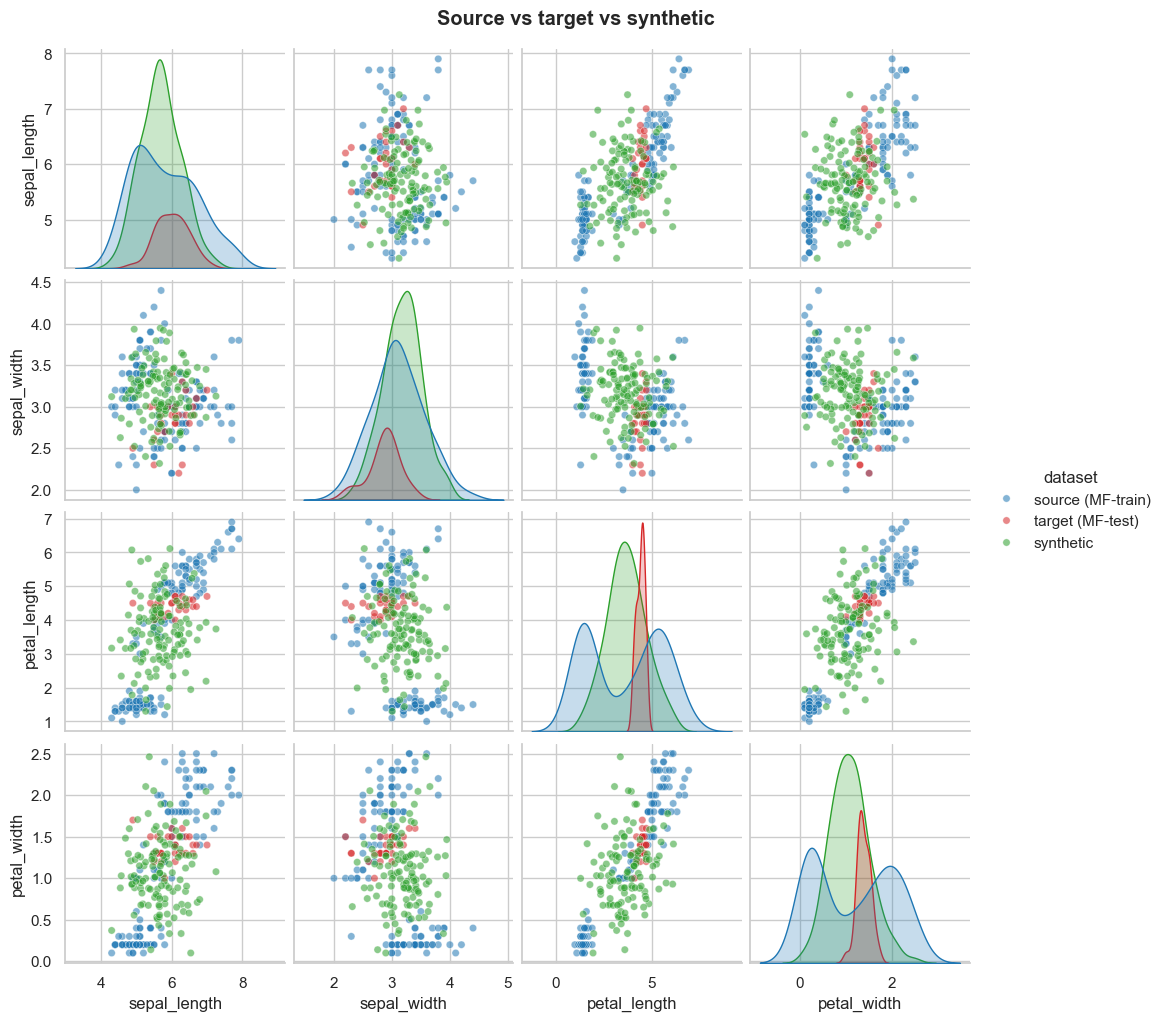

In [7]:
plot_df = pd.concat([
    source_df.assign(dataset="source (MF-train)"),
    target_df.assign(dataset="target (MF-test)"),
    synth_df.assign(dataset="synthetic"),
], ignore_index=True)
g = sns.pairplot(plot_df, vars=FEATURES, hue="dataset", diag_kind="kde",
                 plot_kws={"alpha": 0.55, "s": 28},
                 palette={"source (MF-train)": "#1f77b4",
                          "target (MF-test)": "#d62728",
                          "synthetic": "#2ca02c"})
g.fig.suptitle("Source vs target vs synthetic", y=1.02, fontweight="bold")
plt.show()

## 5. Distance-to-target summary

L2 distance of each meta-feature vector from the target profile (smaller is better).

In [8]:
def mf_distance(df, target_meta):
    return {mf: float(np.linalg.norm(np.asarray(compute_meta_feature(df, mf)) - np.asarray(tv)))
            for mf, tv in target_meta.items()}

summary = pd.DataFrame({
    "source (MF-train)": mf_distance(source_df, target_meta),
    "synthetic":         mf_distance(synth_df,  target_meta),
}).T
summary.columns = [f"||{c} - target||" for c in summary.columns]
summary

,||mut_inf - target||,||iq_range - target||
source (MF-train),1.614681,3.939067
synthetic,0.051629,1.080379
